# Probability Distributions 1

In [1]:
import math
from fractions import Fraction as F

import numpy as np
import scipy as sp
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

## 1 Random Variable

### 1.1 Random Event

#### Definition

An occurrence whose outcome is not predictable with certainty before it happens, even though all possible outcomes are known, is called as Random Event.

#### Examples

1. Weather forecast
2. Stock market prediction
3. Rolling a dice

### 1.2 Random Variable

#### Definition

A random variable is a function that maps outcomes of a random experiment to numerical values.

#### Types of Random Variables

1. Discrete Random Variable
2. Continuous Random Variable

### 1.3 Discrete Random Variable

#### Definition

Variable whose outcome of a random experiment will always be a discrete (non floating) value.

#### Examples

Experiment: Rolling a dice.  
Outcomes: {1, 2, 3, 4, 5, 6}

#### Probability of a Discrete Random Variable

##### Example #1: Rolling a dice

$$
\large
\begin{aligned}
P(X = 2) = \frac{1}{6}
\end{aligned}
$$

Probability that a random variable $X$ takes the value $2$ = $\displaystyle \frac{1}{6}$

### 1.4 Continuous Random Variable

#### Definition

Variable whose outcome of a random experiment will always be a floating value.

#### Examples

Experiment: Measuring Height of human beings.  
Outcomes: floating point number for example 155.1 cm, 160.4 cm

#### Probability of a Continuous Random Variable

##### Example #1: Height of human beings

$$
\large
\begin{aligned}
P(X = x) = 0
\end{aligned}
$$

Probability that a random variable $X$ takes the exact value $160.4$ is always $0$ i.e., $P(X = 160.4\;\text{cm}) = 0$

#### Properties

1. While it is not possible to calculate probability of a continuous random variable taking an exact value,  
   its possible to calculate the probability of a continuous random variable between some range $(a \le x \le b)$.
2. Probability of a continuous random variable between some range can be calculated using **Probability Density Function (PDF)**.

> **Note**:
>
> While it is possible to calculate probability of a Discrete Random Variable $X$ taking an exact value, it is not possible  
> to calculate probability of a Continuous Random Variable $X$ taking some exact value. Hence it is considered as zero.

### 1.5 Distribution

#### Definition

Distribution is a mathematical function or chart that shows all possible values a random variable can take and how frequently they occur.

##### How to Visualize Distribution?

Plotting data-points on a Histogram.

#### Properties

1. Distribution describes the spread, pattern and frequency of outcomes within a dataset or for a random variable.
2. It provides a mathematical description of behavior of the data which indicate where most data points are concentrated and how they are spread out.
3. Distributions can be represented in various forms such as Probability Density Functions (PDF) for continuous data or Probability Mass Functions (PMF) for discrete data.

> **Note**:
>
> Concentration of data-points is indicated by Distributions.

#### Types of Distributions

1. Discrete Distributions
2. Continuous Distributions

### 1.6 Expected Value

#### Definition

* Expectation of a random variable X is the weighted average of the values that X takes, with the weights beings the probabilities.
* Expected Value of a Random Variable X is the product of values (that X can take) and its probability i.e., weighted average of probability.

## 2 Probability Distribution Functions

### 2.1 Probability Mass Function

#### Definition

* PMF is a distribution function that describes the **probability** of a **discrete random variable** taking on a **specific value**.
* Graphical representation of probability on a distributed data is called as Probability Mass Function.

#### Equation

$$
\large
\begin{aligned}
P(X = x) = f(x)
\end{aligned}
$$

Where,

- $X$ - Discrete Random Variable
- $x$ - Specific value of a Discrete Random Variable for which the Probability needs to be calculated
- $f(x)$ -  is the probability that the Discrete Random variable $X$ takes the exact value $x$

#### Properties

1. PMF maps each possible value of a discrete random variable to the probability that the random variable takes that value.

### 2.2 Probability Density Function

#### Definition

* PDF is a distribution function that describes the **probability density** of a **continuous random variable** between some **range**.
* The term "density" here is similar to how tightly data is packed around a specific point.

#### Equation

$$
\large
\begin{aligned}
P(a \le X \le b) = \int_{a}^{b} f(x)\,dx
\end{aligned}
$$

#### Properties

1. PDF is used for **continuous random variables**, as opposed to PMF, which is for discrete variables.
2. PDF does not provide the probability of a specific value but gives the **probability of the random variable falling within a certain interval**.
3. Probability of a specific value in PDF is Zero.
4. To calculate probability of some range we have to calculate the area under the curve. Area under the curve is calculated using Integration.

### 2.3 Cumulative Distribution Function

#### Definition

CDF is a distribution function that gives the probability that a random variable (Discrete/Continuous) is less than or equal to a specified value.

$$
\large
\begin{aligned}
F(x) = P(X \le x)
\end{aligned}
$$

#### Equations

CDF for Discrete Random Variable $X$ :

$$
\large
\begin{aligned}
F(x) = P(X \le x) = \sum_{t \le x} P(X = t)
\end{aligned}
$$

CDF for Continuous Random Variable $X$ :

$$
\large
\begin{aligned}
F(x) = P(X \le x) = \int_{-\infty}^{x} f(t)\,dt
\end{aligned}
$$

#### Properties

1. Use integration to get area under the curve to get CDF from PDF.
2. Use differentiation to get PDF from CDF.

##### Range

Probability Between Range for Discrete Random Variable $X$ :

$$
\large
\begin{aligned}
P(a < X \le b) = F(b) - F(a)
\end{aligned}
$$

Probability Between Range for Continuous Random Variable $X$ :

$$
\large
\begin{aligned}
P(a \le X \le b) = F(b) - F(a) \\[10pt]
\text{Where,}\;\; P(X = a) = 0
\end{aligned}
$$

## 3 Empirical vs Theoretical Probability

### 3.1 Case Study

Experiment: There are 3 Red balls and 2 Blue balls in a bucket. Pick a ball four times from the bucket.  

Problem:

1. Calculate the probability of all four picks being red.
2. Calculate the expected value.

There are two ways to find probability:

1. Empirical approach
2. Theoretical approach

### 3.2 Empirical Approach

1. Trying to find probabilities experimentally.
2. In empirical approach, the experiment is done N number of time, say 10,000, and then the result is concluded.

#### Simulation

In [2]:
def empirical_approach(bucket, simulation: int = 10_000) -> list[int]:
    """
    Function to perform experiment using empirical approach.
    """
    trial = 4
    red_counts: list[int] = []

    for _ in range(simulation):
        # Define event for experiment and save outcome.
        outcomes = np.random.choice(bucket, size=trial)

        # Count total number of red balls in outcomes.
        red_count: int = len(np.where(outcomes == "R")[0])

        # Collect experiment result.
        red_counts.append(red_count)

    return red_counts

#### Probabilities

In [3]:
# Bucket with 3 red & 2 blue balls.
bucket = ["R", "R", "R", "B", "B"]
output = empirical_approach(bucket)

df = pd.Series(output).value_counts(normalize=True).sort_index().to_frame(name="Probability")
df

,Probability
0,0.0232
1,0.1643
2,0.3390
3,0.3487
4,0.1248


In [4]:
emp_prob = df.loc[4, "Probability"].item()
print("Probability of picking red balls:", emp_prob)

Probability of picking red balls: 0.1248


#### Probability Mas Function

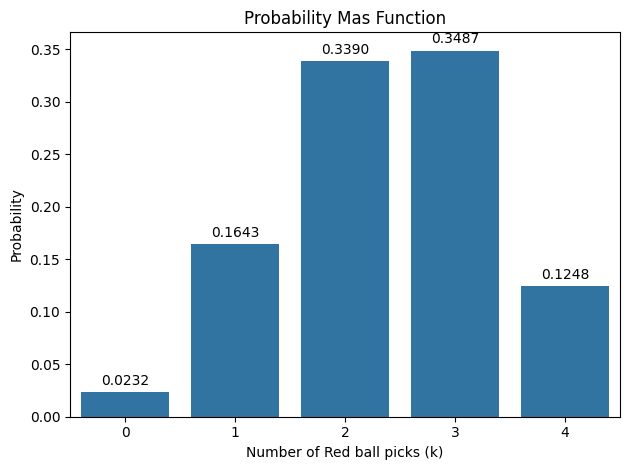

In [5]:
ax = sns.barplot(data=df, x=df.index, y="Probability")
ax.bar_label(ax.containers[0], fmt="%.4f", padding=3)
plt.title("Probability Mas Function")
plt.xlabel("Number of Red ball picks (k)")
plt.tight_layout()
plt.show()

#### Expected Value

In [6]:
emp_expv = np.mean(output).item()
print("Expected value based on Empirical approach:", emp_expv)

Expected value based on Empirical approach: 2.3876


In [7]:
theo_expv = np.sum(df.index * df["Probability"]).round(6).item()
print("Expected value based on Empirical approach:", theo_expv)

Expected value based on Empirical approach: 2.3876


##### Interpretation of Expected value

The Expected Value of 2.4 means that we will get 2.4 (i.e., 2 or 3) number of red balls on an average if we we perform this experiment large number of times.

#### Disadvantages of Empirical Approach

1. Empirical Approach may not be feasible every time.
2. Empirical Approach can be very costly in terms of time and resources.

### 3.3 Theoretical Approach

In theoretical approach, the experiment is conducted purely using mathematics.

In [8]:
def C(n, k):
    """
    Function to compute combinations as fractions.
    """
    return F(math.comb(n, k))


def P(n, d):
    """
    Function to represent probability as fractions.
    """
    return F(n, d)

#### Probabilities

In [9]:
# Bucket with 3 red & 2 blue balls.
bucket = ["R", "R", "R", "B", "B"]

p_red = P(3, 5)
p_blue = P(2, 5)

print("Probability of picking red ball:", p_red)
print("Probability of picking blue ball:", p_blue)

Probability of picking red ball: 3/5
Probability of picking blue ball: 2/5


In [10]:
theo_prob = p_red**4
print("Probability of picking red ball in four trials:", theo_prob, "or", float(theo_prob))

Probability of picking red ball in four trials: 81/625 or 0.1296


### 3.4 Conclusion

#### Empirical value vs Theoretical value

##### Probability

In [11]:
print("Empirical vs Theoretical Probability are very close:")
emp_prob, float(theo_prob)

Empirical vs Theoretical Probability are very close:


(0.1248, 0.1296)

##### Expected Value

In [12]:
print("Empirical vs Theoretical Expected-value are very close:")
emp_expv, theo_expv

Empirical vs Theoretical Expected-value are very close:


(2.3876, 2.3876)

## 4 Binomial Distribution

### 4.1 What is Binomial Distribution?

#### Definition

Binomial distribution is a **discrete** probability distribution of the **number of successes** in $n$ independent experiments sequence.

A Binomial trial will always have two possible outcomes:

* Success / Win
* Failure / Loss

#### B.I.N.S. Conditions

- **B** - Binary Outcomes: Each trial has only two possible outcomes.
- **I** - Independent Trials: The outcome of one trial does not affect the next.
- **N** - Number of Trials: The experiment is repeated a fixed number of times $n$.
- **S** - Same probability: Either success or failure probability should be given and it remains same for every trial.

#### Formulas

##### Probability

Given $p$ the probability of success, Binomial distribution helps us in calculating $k$ successes from $n$ trials.

$$
\large
\begin{aligned}
P\bigl(X = k\bigr) = {}^nC_k \cdot p^k \cdot \bigl(1 - p\bigr)^{n - k}
\end{aligned}
$$

Where,

- $n$ - Total number of trials
- $k$ - Number of successful events
- $p$ - Probability of success

##### Expected Value

$$
\large
\begin{aligned}
E\bigl[X\bigr] = n \cdot p
\end{aligned}
$$

Where,

- $n$ - Total number of trials
- $p$ - Probability of success

##### Variance

$$
\large
\begin{aligned}
\sigma^2(x) = n \cdot p \cdot (1 - p)
\end{aligned}
$$

Where,

- $n$ - Total number of trials
- $p$ - Probability of success

### 4.2 Examples

#### Quiz #1

A bag has 3 red balls and 2 blue balls.  
A ball in chosen at random 4 times.  
What is the probability of getting:

1. Zero red balls
2. One red balls
3. Two red balls
4. Three red balls
5. Four red balls

##### Solution

In [13]:
p = 3 / 5  # Probability of success.
n = 4  # Number of trails.
# k = 0, 1, 2, 3, 4  # Random variable x taking k values.

In [14]:
p_k0 = sp.stats.binom.pmf(p=p, k=0, n=n).round(4).item()
p_k1 = sp.stats.binom.pmf(p=p, k=1, n=n).round(4).item()
p_k2 = sp.stats.binom.pmf(p=p, k=2, n=n).round(4).item()
p_k3 = sp.stats.binom.pmf(p=p, k=3, n=n).round(4).item()
p_k4 = sp.stats.binom.pmf(p=p, k=4, n=n).round(4).item()

p_k0, p_k1, p_k2, p_k3, p_k4

(0.0256, 0.1536, 0.3456, 0.3456, 0.1296)

In [15]:
sp.stats.binom.expect(args=(n, p)).round(2).item()

2.4

#### Quiz #2

A factory produces LED bulbs, and each bulb has a 5% chance of being defective.  
A quality inspector randomly selects 20 bulbs from the production line.  

What is the probability that exactly 2 bulbs are defective?

##### Solution

In [16]:
p = 0.05
n = 20
x = 2

In [17]:
p_x2 = sp.stats.binom.pmf(p=0.05, n=20, k=2)
p_x2.round(4).item()

0.1887

#### Quiz #3

Suppose that we float 10 quizzes, with 4 options each.  
Only 1 option is correct, and we are guessing the answers.  
What is the probability that we will get **at least 4** answers correct?

##### Solution

In [18]:
p = 1 / 4
n = 10
# k = 4, 5, 6, 7, 8, 9, 10
# Find: P(x >= 4)
# P(x >= 4) = 1 - P(x < 3)

###### Using PMF

In [19]:
p_k0 = sp.stats.binom.pmf(p=p, k=0, n=n)
p_k1 = sp.stats.binom.pmf(p=p, k=1, n=n)
p_k2 = sp.stats.binom.pmf(p=p, k=2, n=n)
p_k3 = sp.stats.binom.pmf(p=p, k=3, n=n)

p_x_ge_4 = 1 - (p_k0 + p_k1 + p_k2 + p_k3)

p_x_ge_4.round(4).item()

0.2241

or

In [20]:
p_k04 = sp.stats.binom.pmf(p=p, k=4, n=n)
p_k05 = sp.stats.binom.pmf(p=p, k=5, n=n)
p_k06 = sp.stats.binom.pmf(p=p, k=6, n=n)
p_k07 = sp.stats.binom.pmf(p=p, k=7, n=n)
p_k08 = sp.stats.binom.pmf(p=p, k=8, n=n)
p_k09 = sp.stats.binom.pmf(p=p, k=9, n=n)
p_k10 = sp.stats.binom.pmf(p=p, k=10, n=n)

p_tot = p_k04 + p_k05 + p_k06 + p_k07 + p_k08 + p_k09 + p_k10
p_tot.round(4).item()

0.2241

###### Using CDF

In [21]:
# Find: P(X >= 4)
# 1 - P(x < 3)

In [22]:
p_x_ge_4 = 1 - sp.stats.binom.cdf(k=3, p=p, n=n)
p_x_ge_4.round(4).item()

0.2241

#### Quiz #4

Suppose that we float 10 quizzes, with 4 options each. Only 1 option is correct.  
What is the probability that we will get exactly 2 answers correct?

##### Solution

In [23]:
p = 1 / 4
n = 10
x = 2

In [24]:
p_k2 = sp.stats.binom.pmf(k=x, p=p, n=n)
p_k2.round(4).item()

0.2816

### 4.3 Bernoulli Trial

#### Definition

Bernoulli Trial is a special case of Binomial Distribution when the trial count is fixed to one.

#### Formulas

##### Probability

Given $p$ the probability of success, Bernoulli Trial helps us in calculating $k$ successes from $1$ trials.

$$
\large
\begin{aligned}
P(X = k) = p^k \cdot (1 - p)^{1 - k}
\end{aligned}
$$

Where,

- $k$ - Number of successful events
- $p$ - Probability of success

##### Expected Value

$$
\large
\begin{aligned}
E[X] = p
\end{aligned}
$$

Where,

- $p$ - Probability of success

##### Variance

$$
\large
\begin{aligned}
\sigma^2(x) = p \cdot (1 - p)
\end{aligned}
$$

Where,

- $p$ - Probability of success

> **Note**:
>
> Binomial distribution is a collection of Bernoulli Trials.

#### Examples

##### Example #1

You toss 2 dice:

1. if both dice are 6, you get Rs 2.
2. else if one dice is 6, you get Rs 1.

Otherwise, you do not get anything

In [25]:
k2 = sp.stats.binom.pmf(n=2, p=1 / 12, k=2)
k2 = sp.stats.binom.pmf(n=2, p=1 / 6, k=2)
k2.round(4).item()

0.0278